## 03_pancreas_dataloader_basico.ipynb
 Objetivo:
 1) construir Dataset y DataLoader para PANCREAS
 2) leer volúmenes .nii.gz correctamente
 3) aplicar preprocesado 3D robusto:
    - saneamiento HU
    - resampling con spacing real
    - clipping HU [-1000, 400]
   - normalización a [0,1]
    - ajuste final a 64x64x64
 4) devolver tensores listos para entrenamiento

## imports

In [29]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

import SimpleITK as sitk
import scipy.ndimage as ndi

## configuración global

In [30]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path("/mnt/d/Universidad/analitica/proyecto_analitica2")
DATA_DIR = PROJECT_ROOT / "data"
MANIFESTS_DIR = DATA_DIR / "manifests"

MANIFEST_PATH = MANIFESTS_DIR / "manifest_pancreas.csv"
SPLIT_PATH = MANIFESTS_DIR / "split_final_pancreas.csv"

TARGET_SHAPE = (64, 64, 64)   # (D, H, W)
HU_MIN = -150
HU_MAX = 250

# spacing objetivo para resampling físico
TARGET_SPACING = (1.0, 1.0, 1.5)

BATCH_SIZE = 2
NUM_WORKERS = 2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
print("TARGET_SHAPE:", TARGET_SHAPE)
print("TARGET_SPACING:", TARGET_SPACING)

DEVICE: cuda
TARGET_SHAPE: (64, 64, 64)
TARGET_SPACING: (1.0, 1.0, 1.5)


## cargar manifest y split

In [31]:
manifest = pd.read_csv(MANIFEST_PATH)
split_df = pd.read_csv(SPLIT_PATH)

df = manifest.merge(
    split_df[["case_id", "split"]],
    on="case_id",
    how="left"
)

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

print("\nDistribución train:")
print(train_df["label_binary"].value_counts())

train: (392, 15)
val: (82, 15)
test: (83, 15)

Distribución train:
label_binary
0    281
1    111
Name: count, dtype: int64


## leer imagen

In [32]:
def read_ct_image(path):
    image = sitk.ReadImage(str(path))
    return image

## sanear intensidades HU

In [33]:
def sanitize_hu_sitk(image, lower_bound=-1024):
    volume = sitk.GetArrayFromImage(image).astype(np.float32)  # [D, H, W]
    volume[volume < lower_bound] = lower_bound

    clean_image = sitk.GetImageFromArray(volume)
    clean_image.SetSpacing(image.GetSpacing())
    clean_image.SetOrigin(image.GetOrigin())
    clean_image.SetDirection(image.GetDirection())
    return clean_image

## resampling por spacing real

In [34]:
def resample_image_spacing(image, out_spacing=(1.0, 1.0, 1.5), is_label=False):
    original_spacing = image.GetSpacing()   # (x, y, z)
    original_size = image.GetSize()         # (x, y, z)

    out_size = [
        int(np.round(original_size[i] * (original_spacing[i] / out_spacing[i])))
        for i in range(3)
    ]

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)
    resample.SetOutputDirection(image.GetDirection())
    resample.SetOutputOrigin(image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(float(-1024))

    if is_label:
        resample.SetInterpolator(sitk.sitkNearestNeighbor)
    else:
        resample.SetInterpolator(sitk.sitkLinear)

    return resample.Execute(image)

## clipping y normalización

In [35]:
def clip_and_normalize_hu(volume, hu_min=HU_MIN, hu_max=HU_MAX):
    volume = np.clip(volume, hu_min, hu_max)
    volume = (volume - hu_min) / (hu_max - hu_min)
    volume = np.clip(volume, 0.0, 1.0)
    return volume.astype(np.float32)

## resize final a shape fija

In [36]:
def resize_volume_to_shape(volume, target_shape=TARGET_SHAPE, order=1):
    d, h, w = volume.shape
    td, th, tw = target_shape

    zoom_factors = (
        td / d,
        th / h,
        tw / w,
    )

    resized = ndi.zoom(volume, zoom=zoom_factors, order=order)
    return resized.astype(np.float32)

## pipeline completo de preprocesado

In [37]:
def preprocess_ct_from_path(
    image_path,
    target_spacing=TARGET_SPACING,
    target_shape=TARGET_SHAPE,
    hu_min=HU_MIN,
    hu_max=HU_MAX,
):
    image = read_ct_image(image_path)
    image = sanitize_hu_sitk(image, lower_bound=-1024)
    image = resample_image_spacing(image, out_spacing=target_spacing, is_label=False)

    volume = sitk.GetArrayFromImage(image).astype(np.float32)  # [D, H, W]
    volume = clip_and_normalize_hu(volume, hu_min=hu_min, hu_max=hu_max)
    volume = resize_volume_to_shape(volume, target_shape=target_shape, order=1)

    return volume, image

## Dataset

In [38]:
class PancreasVolumeDataset(Dataset):
    def __init__(self, df, target_spacing=TARGET_SPACING, target_shape=TARGET_SHAPE):
        self.df = df.reset_index(drop=True).copy()
        self.target_spacing = target_spacing
        self.target_shape = target_shape

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        volume, processed_image = preprocess_ct_from_path(
            row["image_path"],
            target_spacing=self.target_spacing,
            target_shape=self.target_shape,
            hu_min=HU_MIN,
            hu_max=HU_MAX,
        )

        x = torch.from_numpy(volume).unsqueeze(0)  # [1, D, H, W]
        y = torch.tensor(int(row["label_binary"]), dtype=torch.long)

        meta = {
            "case_id": row["case_id"],
            "patient_id": row["patient_id"],
            "split": row["split"],
            "image_path": row["image_path"],
            "label_str": row["label_str"],
            "processed_spacing_xyz": processed_image.GetSpacing(),
            "processed_size_xyz": processed_image.GetSize(),
            "has_manual_label": int(pd.notna(row["manual_label_path"])),
            "has_automatic_label": int(pd.notna(row["automatic_label_path"])),
        }

        return x, y, meta

## instanciar datasets

In [39]:
train_ds = PancreasVolumeDataset(
    train_df,
    target_spacing=TARGET_SPACING,
    target_shape=TARGET_SHAPE
)

val_ds = PancreasVolumeDataset(
    val_df,
    target_spacing=TARGET_SPACING,
    target_shape=TARGET_SHAPE
)

test_ds = PancreasVolumeDataset(
    test_df,
    target_spacing=TARGET_SPACING,
    target_shape=TARGET_SHAPE
)

print("len(train_ds):", len(train_ds))
print("len(val_ds):", len(val_ds))
print("len(test_ds):", len(test_ds))

len(train_ds): 392
len(val_ds): 82
len(test_ds): 83


## probar una muestra

In [40]:
x, y, meta = train_ds[0]

print("x.shape:", x.shape)   # [1, D, H, W]
print("y:", y.item())
print("meta:", meta)
print("x min/max:", float(x.min()), float(x.max()))
print("x dtype:", x.dtype)

x.shape: torch.Size([1, 64, 64, 64])
y: 0
meta: {'case_id': '100000_00001', 'patient_id': np.int64(100000), 'split': 'train', 'image_path': '/mnt/d/Universidad/analitica/proyecto_analitica2/data/source/pancreas/100000_00001_0000.nii.gz', 'label_str': 'non-PDAC', 'processed_spacing_xyz': (1.0, 1.0, 1.5), 'processed_size_xyz': (356, 356, 144), 'has_manual_label': 0, 'has_automatic_label': 1}
x min/max: 0.0 1.0
x dtype: torch.float32


## visualizar una muestra preprocesada

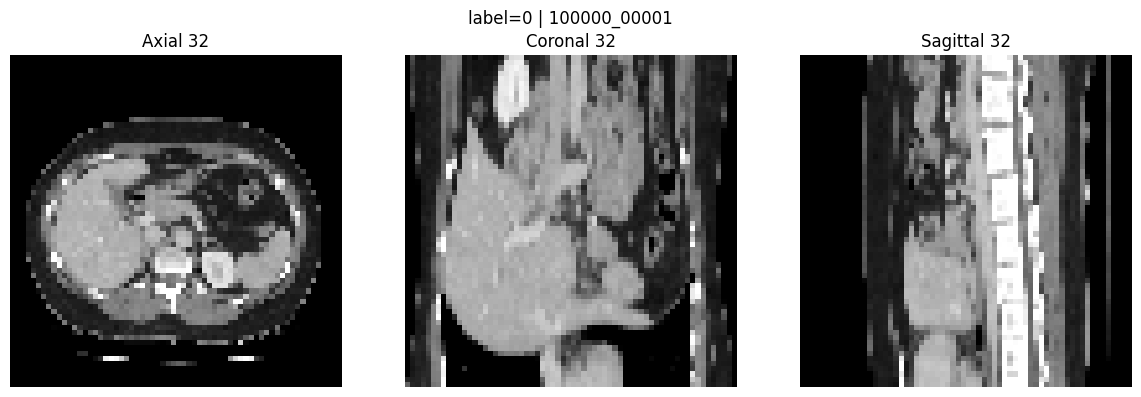

In [41]:
def show_processed_volume(x, title=""):
    vol = x.squeeze(0).numpy()  # [D, H, W]
    d, h, w = vol.shape
    dc, hc, wc = d // 2, h // 2, w // 2

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(vol[dc], cmap="gray")
    axes[0].set_title(f"Axial {dc}")
    axes[0].axis("off")

    axes[1].imshow(vol[:, hc, :], cmap="gray")
    axes[1].set_title(f"Coronal {hc}")
    axes[1].axis("off")

    axes[2].imshow(vol[:, :, wc], cmap="gray")
    axes[2].set_title(f"Sagittal {wc}")
    axes[2].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_processed_volume(x, title=f"label={y.item()} | {meta['case_id']}")

## collate function

In [42]:
def simple_collate(batch):
    xs, ys, metas = zip(*batch)
    xs = torch.stack(xs, dim=0)   # [B, 1, D, H, W]
    ys = torch.stack(ys, dim=0)   # [B]
    return xs, ys, metas

## DataLoaders

In [43]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=simple_collate
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=simple_collate
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=simple_collate
)

## probar un batch

In [44]:
xb, yb, metab = next(iter(train_loader))

print("xb.shape:", xb.shape)
print("yb.shape:", yb.shape)
print("yb:", yb.tolist())
print("xb min/max:", float(xb.min()), float(xb.max()))
print("xb dtype:", xb.dtype)

xb.shape: torch.Size([2, 1, 64, 64, 64])
yb.shape: torch.Size([2])
yb: [1, 0]
xb min/max: 0.0 1.0
xb dtype: torch.float32


## visualizar un ejemplo del batch

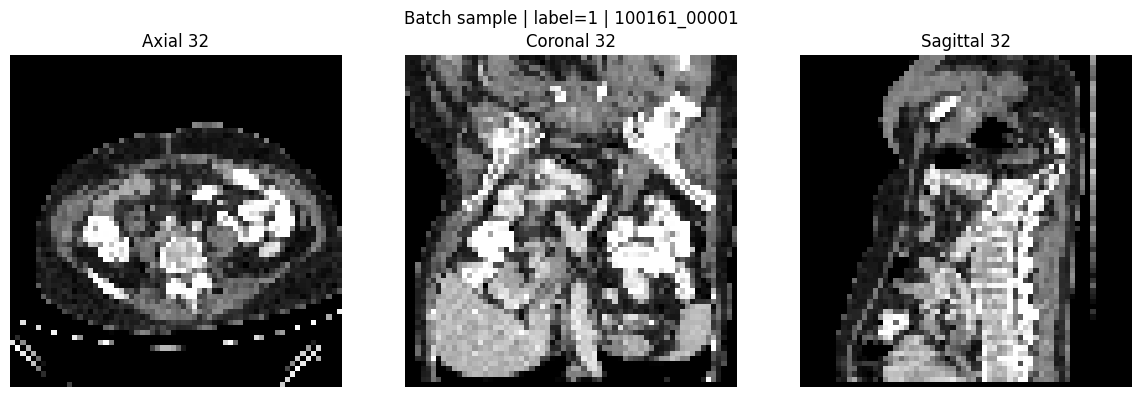

In [45]:
sample_idx = 0
show_processed_volume(
    xb[sample_idx],
    title=f"Batch sample | label={yb[sample_idx].item()} | {metab[sample_idx]['case_id']}"
)

## resumen final del dataloader

In [46]:
print("Resumen final dataloader PANCREAS")
print("-" * 40)
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))
print("Target shape:", TARGET_SHAPE)
print("Target spacing:", TARGET_SPACING)
print("HU range:", (HU_MIN, HU_MAX))
print("Batch size:", BATCH_SIZE)
print("Device:", DEVICE)

Resumen final dataloader PANCREAS
----------------------------------------
Train size: 392
Val size: 82
Test size: 83
Target shape: (64, 64, 64)
Target spacing: (1.0, 1.0, 1.5)
HU range: (-150, 250)
Batch size: 2
Device: cuda
